# CME 241 — Phase 2 C: Multi-Strategy Statistical Arbitrage via Dynamic Programming

**Multi-Strategy Statistical Arbitrage for Finance Optimization**

---

## Pipeline Overview

```
CRSP Daily Panel
      │
  ┌───▼────────────────────────────────────────────┐
  │ Step 1: Data Ingestion & Quality Gates         │
  │   • Uniqueness, delistings, outlier policy     │
  └───┬────────────────────────────────────────────┘
      │
  ┌───▼────────────────────────────────────────────┐
  │ Step 2: Three Strategy Return Streams          │
  │   • Conservative: PCA residual mean reversion  │
  │   • Medium:       Pairs trading (spread z-score)│
  │   • Aggressive:   VRP proxy (short-vol profile) │
  └───┬────────────────────────────────────────────┘
      │
  ┌───▼────────────────────────────────────────────┐
  │ Step 3: Calibrate Parametric Return Model      │
  │   • Gaussian (regime-switching, 2-state)       │
  └───┬────────────────────────────────────────────┘
      │
  ┌───▼────────────────────────────────────────────┐
  │ Step 4: Phase-2 MDP                            │
  │   • States: wealth × regime                   │
  │   • Actions: 10 discrete risk-ladder allocations│
  │     (Conservative → Aggressive + Cash tiers)  │
  └───┬────────────────────────────────────────────┘
      │
  ┌───▼────────────────────────────────────────────┐
  │ Step 5: DP Solution (Value/Policy Iteration)   │
  │   • Optimal policy π*(wealth, regime)          │
  └───┬────────────────────────────────────────────┘
      │
  ┌───▼────────────────────────────────────────────┐
  │ Step 6: OOS Evaluation & Ablations             │
  │   • Metrics, stress periods, leakage tests    │
  └────────────────────────────────────────────────┘
```

**Convention**: Decision at time $t$ → positions held over $(t, t+1]$.  
$\text{PnL}_{t+1} = w_t^\top r_{t+1}$  (lagged exposures throughout).

In [1]:
import sys
import os
import logging

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Ensure the repo root is on the path
REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

# Configure logging so we can see pipeline progress
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s  %(name)s  %(levelname)s  %(message)s",
    datefmt="%H:%M:%S",
)

from project_code_c import (
    load_crsp, integrity_checks,
    apply_missing_data_policy, winsorize_returns, build_full_pipeline,
    assign_regime,
    build_strategy_series,
    calibrate, CalibrationParams,
    ACTIONS, ACTION_NAMES, MDPConfig, build_mdp, crra_utility, make_wealth_grid,
    solve, solve_and_plot, policy_summary,
    backtest_policy, compute_metrics, print_metrics_table, plot_backtest,
    run_leakage_shift_test, run_leakage_permute_test,
)
from project_code_c.backtest.runner import backtest_fixed_allocation
from project_code_c.env.simulator import GaussianSampler, BlockBootstrapSampler

print("Imports OK.")

Imports OK.


---
## Step 1 — Data Ingestion & Quality Gates

Load the CRSP daily S&P 500 panel, run integrity checks, apply the missing-data policy, and winsorize returns for signal construction.

In [2]:
CRSP_PATH = "crsp_daily_sp500.csv"   # relative to Project/

df_clean, dropped_dates = build_full_pipeline(
    path=CRSP_PATH,
    min_coverage=0.90,
    winsor_window=63,
    z_cap=3.0,
    start_date="2002-01-01",  # consistent with earlier phases
    save_cleaned_to=None,     # set to a .parquet path to cache
)

print(f"Clean panel: {len(df_clean):,} rows | {df_clean['PERMNO'].nunique():,} PERMNOs")
print(f"Date range : {df_clean['date'].min().date()} to {df_clean['date'].max().date()}")
print(f"Dropped dates (low coverage): {len(dropped_dates)}")

# Quality gate assertion (should always hold after pipeline)
assert df_clean.duplicated(subset=["PERMNO", "date"]).sum() == 0, "Duplicate keys found!"
assert not np.isinf(df_clean["RET"].dropna()).any(), "Infinite returns found!"
print("Quality gates passed.")

12:35:52  project_code_c.data.ingest  INFO  Loaded 8480706 rows | 1003 unique PERMNOs | 1960-01-04 to 2023-03-31
12:36:00  project_code_c.data.ingest  INFO  SHRCD/EXCHCD filter: 8480706 → 8213445 rows (removed 267261).
12:36:00  project_code_c.data.ingest  INFO  374 PERMNOs have >1 TICKER (PERMNO used as stable ID).
12:36:01  project_code_c.data.ingest  WARNING  4518 rows in (PERMNO,date) duplicates — keeping row with valid RET.
12:36:04  project_code_c.data.ingest  WARNING  229 observations with |RET|>50% (flagged, not removed). Top PERMNOs: {76757: 8, 89301: 8, 90162: 6, 11042: 5, 51043: 5}
12:36:04  project_code_c.data.ingest  INFO  Merging DLRET into final RET for 39 PERMNOs.
12:36:04  project_code_c.data.ingest  INFO  Integrity checks: 8480706 → 8211167 rows (removed 269539).
12:36:06  project_code_c.data.clean  INFO  NA POLICY — forward-fill PRC: 1941 NaN → 0 remaining (100.0% filled).
12:36:06  project_code_c.data.clean  INFO  NA POLICY — forward-fill VOL: 194325 NaN → 190925 re

Clean panel: 3,529,228 rows | 908 PERMNOs
Date range : 2002-01-02 to 2023-03-31
Dropped dates (low coverage): 1
Quality gates passed.


---
## Step 2 — Three Strategy Return Streams

Build three causal daily return series:

| Strategy | Style | Description |
|---|---|---|
| `strat1_ret` | Conservative | PCA residual mean reversion (Avellaneda-Lee) |
| `strat2_ret` | Medium | Pairs trading via rolling correlation + spread z-score |
| `strat3_ret` | Aggressive | VRP proxy (long low-current-vol stocks, regime-filtered) |

> **Note**: The conservative strategy takes ~5-10 min on the full panel. Set `pca_window=63` and `medium_n_pairs=10` to speed up during development.

In [3]:
strategy_series = build_strategy_series(
    df_clean,
    use_winsorized=True,
    # Conservative (PCA residual mean reversion)
    pca_window=126,
    pca_n_components=5,
    pca_z_threshold=1.5,
    pca_z_window=21,
    # Medium (pairs trading)
    medium_universe_size=150,
    medium_n_pairs=25,
    medium_corr_window=63,
    medium_hedge_window=63,
    medium_z_window=21,
    medium_entry_z=2.0,
    medium_exit_z=0.5,
    medium_rebal_freq=21,
    # Aggressive (VRP proxy)
    agg_rv_short=21,
    agg_rv_long=63,
    agg_top_quintile=0.80,
)

print(f"Strategy series: {len(strategy_series)} days  |  "
      f"{strategy_series.index.min().date()} to {strategy_series.index.max().date()}")
print(strategy_series[["strat1_ret", "strat2_ret", "strat3_ret"]].describe().round(5))

12:37:45  project_code_c.strategies.build  INFO  Building strategy series using return column 'RET_winsor'.
12:40:13  project_code_c.strategies.conservative  INFO  Strategy 1 (PCA residual MR, K=5): 5222 trading days, z_thresh=1.5.
12:43:46  project_code_c.strategies.medium  INFO  Strategy 2 (pairs trading, 25 pairs): 5280 trading days.
12:43:51  project_code_c.strategies.aggressive  INFO  Strategy 3 (VRP proxy, top 20%): 5029 trading days.
12:43:51  project_code_c.strategies.build  INFO  Strategy series pre-dropna: strat1=5222, strat2=5280, strat3=5029, overlap=5029 dates.
12:43:51  project_code_c.strategies.build  INFO  Strategy series: 5029 trading days | 2003-04-10 to 2023-03-31


Strategy series: 5029 days  |  2003-04-10 to 2023-03-31
       strat1_ret  strat2_ret  strat3_ret
count  5029.00000  5029.00000  5029.00000
mean      0.00002     0.00008     0.00065
std       0.00065     0.00348     0.00998
min      -0.00824    -0.02555    -0.06317
25%      -0.00022    -0.00150    -0.00402
50%       0.00003     0.00004     0.00096
75%       0.00026     0.00160     0.00592
max       0.01334     0.06219     0.08030


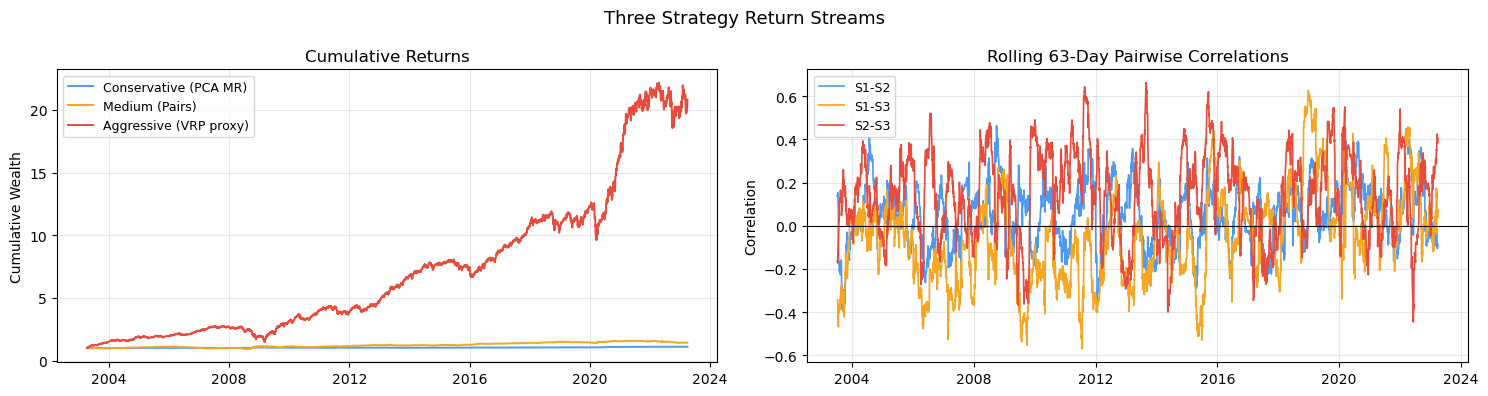

In [4]:
# Visualize cumulative returns and rolling correlations
fig, axes = plt.subplots(1, 2, figsize=(15, 4))
fig.suptitle("Three Strategy Return Streams", fontsize=13)

cum = (1 + strategy_series[["strat1_ret", "strat2_ret", "strat3_ret"]]).cumprod()
colors = ["#4e9af1", "#f5a623", "#e74c3c"]
labels = ["Conservative (PCA MR)", "Medium (Pairs)", "Aggressive (VRP proxy)"]
for i, (col, lbl, clr) in enumerate(zip(cum.columns, labels, colors)):
    axes[0].plot(cum.index, cum[col], label=lbl, color=clr, lw=1.4)
axes[0].set_title("Cumulative Returns")
axes[0].set_ylabel("Cumulative Wealth")
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Rolling 63-day correlations
roll_corr12 = strategy_series["strat1_ret"].rolling(63).corr(strategy_series["strat2_ret"])
roll_corr13 = strategy_series["strat1_ret"].rolling(63).corr(strategy_series["strat3_ret"])
roll_corr23 = strategy_series["strat2_ret"].rolling(63).corr(strategy_series["strat3_ret"])
axes[1].plot(roll_corr12.index, roll_corr12, label="S1-S2", color="#4e9af1", lw=1.2)
axes[1].plot(roll_corr13.index, roll_corr13, label="S1-S3", color="#f5a623", lw=1.2)
axes[1].plot(roll_corr23.index, roll_corr23, label="S2-S3", color="#e74c3c", lw=1.2)
axes[1].axhline(0, color="black", lw=0.8)
axes[1].set_title("Rolling 63-Day Pairwise Correlations")
axes[1].set_ylabel("Correlation")
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## Step 3 — Train / Test Split & Calibration

We use a single chronological split to prevent forward-looking calibration from contaminating the test evaluation.

In [5]:
TRAIN_END   = "2018-12-31"
TEST_START  = "2019-01-01"

train_series = strategy_series[strategy_series.index <= TRAIN_END]
test_series  = strategy_series[strategy_series.index >= TEST_START]

print(f"Train: {train_series.index.min().date()} → {train_series.index.max().date()}  "
      f"({len(train_series)} days)")
print(f"Test : {test_series.index.min().date()}  → {test_series.index.max().date()}  "
      f"({len(test_series)} days)")

# Calibrate on training data only
params = calibrate(
    train_series,
    market_col="vwretd",
    regime_window=21,
    include_regime=True,
)

print("\nCalibrated parameters:")
print(params.describe())

12:45:09  project_code_c.env.simulator  INFO  Regime: 2104 good, 1855 bad days.
12:45:09  project_code_c.env.simulator  INFO  
=== CalibrationParams (3-strategy) ===
  Period : 2003-04-10 → 2018-12-31  (3959 obs)

  Unconditional
    Strategy 1 : μ=+0.00001  σ=0.00058
    Strategy 2 : μ=+0.00011  σ=0.00357
    Strategy 3 : μ=+0.00064  σ=0.00965
    ρ(1,2)=0.1164  ρ(1,3)=-0.0476  ρ(2,3)=0.1120

  Regime-conditional  (2104 good, 1855 bad days)
    Good  μ=(-0.00000, +0.00005, +0.00078)
    Bad   μ=(+0.00003, +0.00018, +0.00049)

  Regime transition matrix  [bad→, good→]
    bad  row : [0.93743258 0.06256742]
    good row : [0.05513308 0.94486692]


Train: 2003-04-10 → 2018-12-31  (3959 days)
Test : 2019-01-02  → 2023-03-31  (1070 days)

Calibrated parameters:
=== CalibrationParams (3-strategy) ===
  Period : 2003-04-10 → 2018-12-31  (3959 obs)

  Unconditional
    Strategy 1 : μ=+0.00001  σ=0.00058
    Strategy 2 : μ=+0.00011  σ=0.00357
    Strategy 3 : μ=+0.00064  σ=0.00965
    ρ(1,2)=0.1164  ρ(1,3)=-0.0476  ρ(2,3)=0.1120

  Regime-conditional  (2104 good, 1855 bad days)
    Good  μ=(-0.00000, +0.00005, +0.00078)
    Bad   μ=(+0.00003, +0.00018, +0.00049)

  Regime transition matrix  [bad→, good→]
    bad  row : [0.93743258 0.06256742]
    good row : [0.05513308 0.94486692]


---
## Step 4 — Build the Phase-2 MDP

The MDP has:
- **States**: wealth bin × regime (40 × 2 = 80 states)
- **Actions**: 10 discrete allocations forming a risk ladder (Conservative → Conservative+ → Moderate-Low → Moderate → Balanced → Moderate-High → Aggressive) plus three cash-tiered defensive variants (Defensive-20 / Defensive-40 / Cash-heavy)
- **Reward**: CRRA utility increment $R = U(W') - U(W)$, $U(W) = W^{1-\gamma}/(1-\gamma)$
- **Transition**: Monte-Carlo via trivariate Gaussian + regime transition matrix

In [6]:
print("Action table:")
print(f"{'Action':<14}  {'S1':>6}  {'S2':>6}  {'S3':>6}  {'Cash':>6}")
print("-" * 42)
for a_idx, (w1, w2, w3, wc) in ACTIONS.items():
    print(f"  {ACTION_NAMES[a_idx]:<12}  {w1*100:>4.0f}%  {w2*100:>4.0f}%  {w3*100:>4.0f}%  {wc*100:>4.0f}%")

Action table:
Action              S1      S2      S3    Cash
------------------------------------------
  Conservative    70%    20%    10%     0%
  Balanced        40%    40%    20%     0%
  Aggressive      15%    25%    60%     0%
  Cash-heavy      20%    10%    10%    60%


In [7]:
cfg = MDPConfig(
    n_wealth_bins=40,
    wealth_min=0.5,
    wealth_max=2.0,
    initial_wealth=1.0,
    risk_aversion=2.0,
    transaction_cost=0.001,
    n_mc_samples=3000,
    use_regime=True,
    log_spaced_wealth=True,
    rng_seed=42,
)

mdp, wealth_grid, cfg = build_mdp(params, cfg)

print(f"MDP built: {len(mdp.non_terminal_states)} non-terminal states, "
      f"{len(ACTIONS)} actions")
print(f"Wealth grid: [{wealth_grid[0]:.3f}, {wealth_grid[-1]:.3f}]  ({len(wealth_grid)} bins)")

12:45:35  project_code_c.env.mdp  INFO  Building MDP with 2-state regime: 40 × 2 = 80 states, 4 actions.
12:45:35  project_code_c.env.mdp  INFO  MDP built: 80 non-terminal states.


MDP built: 80 non-terminal states, 4 actions
Wealth grid: [0.500, 2.000]  (40 bins)


---
## Step 5 — DP Solution: Value Iteration

Solve for the optimal policy $\pi^*(s) = \arg\max_a Q^*(s, a)$ via value iteration.

12:45:43  project_code_c.dp.solver  INFO  Solving MDP via value_iteration  (γ = 0.9900) …
12:45:43  project_code_c.dp.solver  INFO  Solver finished.


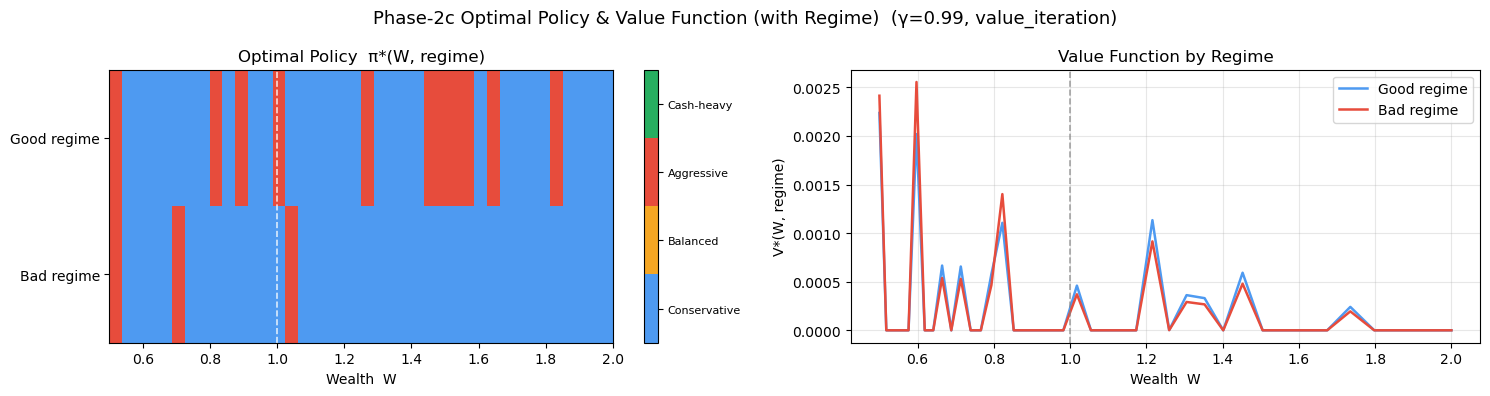

    Wealth    Regime          Action      S1      S2      S3    Cash
--------------------------------------------------------------------
    0.5000      good      Aggressive    15%    25%    60%     0%
    0.5000      bad       Aggressive    15%    25%    60%     0%
    0.5181      good    Conservative    70%    20%    10%     0%
    0.5181      bad     Conservative    70%    20%    10%     0%
    0.5368      good    Conservative    70%    20%    10%     0%
    0.5368      bad     Conservative    70%    20%    10%     0%
    0.5563      good    Conservative    70%    20%    10%     0%
    0.5563      bad     Conservative    70%    20%    10%     0%
    0.5764      good    Conservative    70%    20%    10%     0%
    0.5764      bad     Conservative    70%    20%    10%     0%
    0.5973      good    Conservative    70%    20%    10%     0%
    0.5973      bad       Aggressive    15%    25%    60%     0%
    0.6189      good    Conservative    70%    20%    10%     0%
    0.6189      b

In [8]:
GAMMA = 0.99

opt_vf, opt_policy = solve_and_plot(
    mdp, wealth_grid, cfg=cfg,
    gamma=GAMMA,
    method="value_iteration",
)

print("\nOptimal policy summary (sampled rows):")
policy_summary(opt_policy, wealth_grid, use_regime=cfg.use_regime and params.has_regime,
               max_rows=16)

---
## Step 6 — Out-of-Sample Backtest

Apply the solved policy to the held-out test period (2019 onwards).  
Compare against fixed-allocation benchmarks.


Strategy             Ann.Return   Ann.Vol    Sharpe     MaxDD      FinalW
-------------------------------------------------------------------------
  MDP Policy             +2.74%     3.44%    +0.797    -6.45%      1.1215
  Conservative           +2.22%     2.52%    +0.879    -3.77%      1.0975
  Balanced               +3.48%     4.47%    +0.778    -6.62%      1.1563
  Aggressive            +10.40%    10.91%    +0.953   -15.39%      1.5221
  Cash-heavy             +1.85%     1.98%    +0.937    -2.96%      1.0810



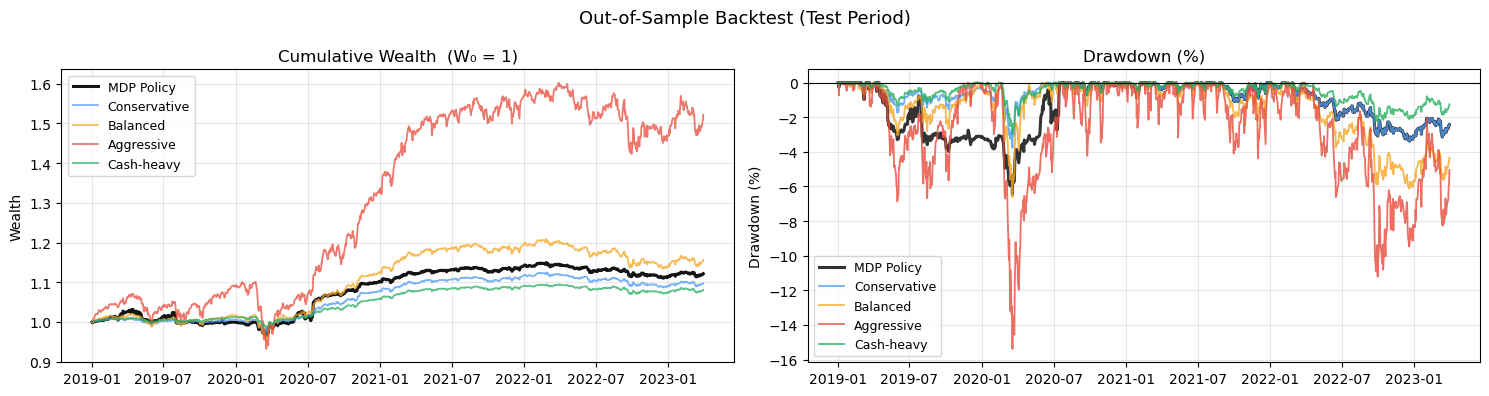

In [9]:
use_regime = cfg.use_regime and params.has_regime

df_backtest = backtest_policy(
    opt_policy,
    test_series,
    wealth_grid,
    cfg=cfg,
    use_regime=use_regime,
    show_plot=True,
)

---
## Step 7 — Policy Iteration Comparison

Verify that policy iteration converges to the same optimal policy.

In [10]:
opt_vf_pi, opt_policy_pi = solve(
    mdp, gamma=GAMMA, method="policy_iteration"
)

df_backtest_pi = backtest_policy(
    opt_policy_pi, test_series, wealth_grid,
    cfg=cfg, use_regime=use_regime, show_plot=False,
)

# Compare value function convergence
from rl.markov_process import NonTerminal
vf_vi = np.array([opt_vf[s] for s in mdp.non_terminal_states])
vf_pi = np.array([opt_vf_pi[s] for s in mdp.non_terminal_states])
max_diff = np.max(np.abs(vf_vi - vf_pi))
print(f"Max |V_VI - V_PI| = {max_diff:.6f}  (should be ≈ 0)")

# Wealth comparison
sharpe_vi = compute_metrics(df_backtest["MDP Policy"])["sharpe"]
sharpe_pi = compute_metrics(df_backtest_pi["MDP Policy"])["sharpe"]
print(f"Sharpe (Value Iteration):  {sharpe_vi:.3f}")
print(f"Sharpe (Policy Iteration): {sharpe_pi:.3f}")

12:46:32  project_code_c.dp.solver  INFO  Solving MDP via policy_iteration  (γ = 0.9900) …
12:46:33  project_code_c.dp.solver  INFO  Solver finished.



Strategy             Ann.Return   Ann.Vol    Sharpe     MaxDD      FinalW
-------------------------------------------------------------------------
  MDP Policy             +2.74%     3.44%    +0.797    -6.45%      1.1215
  Conservative           +2.22%     2.52%    +0.879    -3.77%      1.0975
  Balanced               +3.48%     4.47%    +0.778    -6.62%      1.1563
  Aggressive            +10.40%    10.91%    +0.953   -15.39%      1.5221
  Cash-heavy             +1.85%     1.98%    +0.937    -2.96%      1.0810

Max |V_VI - V_PI| = 0.000002  (should be ≈ 0)
Sharpe (Value Iteration):  0.797
Sharpe (Policy Iteration): 0.797


---
## Step 8 — Stress Period Analysis

Isolate performance during the 2020 COVID crash.

In [11]:
stress_periods = {
    "COVID 2020": ("2020-01-01", "2020-12-31"),
    "Post-COVID 2021": ("2021-01-01", "2021-12-31"),
}

print("\n=== Stress Period Performance ===")
for period_name, (start, end) in stress_periods.items():
    ts_slice = test_series[(test_series.index >= start) & (test_series.index <= end)]
    if len(ts_slice) < 10:
        print(f"  {period_name}: insufficient data.")
        continue
    df_stress = backtest_policy(
        opt_policy, ts_slice, wealth_grid,
        cfg=cfg, use_regime=use_regime, show_plot=False,
    )
    print(f"\n  {period_name}:")
    results = {col: df_stress[col] for col in df_stress.columns}
    print_metrics_table(results)


=== Stress Period Performance ===

Strategy             Ann.Return   Ann.Vol    Sharpe     MaxDD      FinalW
-------------------------------------------------------------------------
  MDP Policy             +8.62%     4.47%    +1.930    -3.51%      1.0865
  Conservative           +7.26%     3.52%    +2.062    -3.51%      1.0729
  Balanced              +10.81%     5.94%    +1.821    -6.47%      1.1086
  Aggressive            +22.47%    13.87%    +1.620   -15.39%      1.2257
  Cash-heavy             +4.64%     2.58%    +1.799    -2.96%      1.0466


  COVID 2020:

Strategy             Ann.Return   Ann.Vol    Sharpe     MaxDD      FinalW
-------------------------------------------------------------------------
  MDP Policy             +8.62%     4.47%    +1.930    -3.51%      1.0865
  Conservative           +7.26%     3.52%    +2.062    -3.51%      1.0729
  Balanced              +10.81%     5.94%    +1.821    -6.47%      1.1086
  Aggressive            +22.47%    13.87%    +1.620   -15.3

---
## Step 9 — Leakage Sanity Checks

### 9a. Signal Shift Test

Shift all strategy returns forward by 1 day (as if we peeked at tomorrow's returns).
A genuine (no look-ahead) strategy should degrade materially.

12:46:57  project_code_c.backtest.evaluate  INFO  Running leakage shift test (shift_days=1) …



Strategy             Ann.Return   Ann.Vol    Sharpe     MaxDD      FinalW
-------------------------------------------------------------------------
  MDP Policy             +2.74%     3.44%    +0.797    -6.45%      1.1215
  Conservative           +2.22%     2.52%    +0.879    -3.77%      1.0975
  Balanced               +3.48%     4.47%    +0.778    -6.62%      1.1563
  Aggressive            +10.40%    10.91%    +0.953   -15.39%      1.5221
  Cash-heavy             +1.85%     1.98%    +0.937    -2.96%      1.0810


Strategy             Ann.Return   Ann.Vol    Sharpe     MaxDD      FinalW
-------------------------------------------------------------------------
  MDP Policy             +2.37%     3.20%    +0.739    -5.97%      1.1043
  Conservative           +2.20%     2.52%    +0.872    -3.77%      1.0966
  Balanced               +3.44%     4.47%    +0.770    -6.62%      1.1545
  Aggressive            +10.33%    10.92%    +0.947   -15.39%      1.5177
  Cash-heavy             +1.84%    

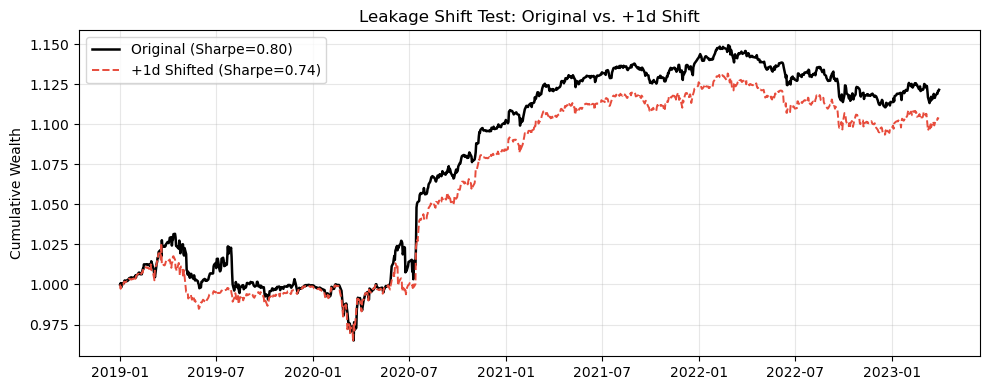

In [12]:
shift_results = run_leakage_shift_test(
    opt_policy, test_series, wealth_grid,
    cfg=cfg, use_regime=use_regime, shift_days=1, show_plot=True,
)

### 9b. Date Permutation Test

Randomly permute the date ordering.  A genuine alpha should collapse to ~0 Sharpe.

12:47:08  project_code_c.backtest.evaluate  INFO  Running leakage permutation test (5 permutations) …



Strategy             Ann.Return   Ann.Vol    Sharpe     MaxDD      FinalW
-------------------------------------------------------------------------
  MDP Policy             +2.74%     3.44%    +0.797    -6.45%      1.1215
  Conservative           +2.22%     2.52%    +0.879    -3.77%      1.0975
  Balanced               +3.48%     4.47%    +0.778    -6.62%      1.1563
  Aggressive            +10.40%    10.91%    +0.953   -15.39%      1.5221
  Cash-heavy             +1.85%     1.98%    +0.937    -2.96%      1.0810


Strategy             Ann.Return   Ann.Vol    Sharpe     MaxDD      FinalW
-------------------------------------------------------------------------
  MDP Policy             +3.48%     4.47%    +0.778    -6.65%      1.1563
  Conservative           +2.22%     2.52%    +0.879    -3.30%      1.0975
  Balanced               +3.48%     4.47%    +0.778    -6.65%      1.1563
  Aggressive            +10.40%    10.91%    +0.953   -13.82%      1.5221
  Cash-heavy             +1.85%    

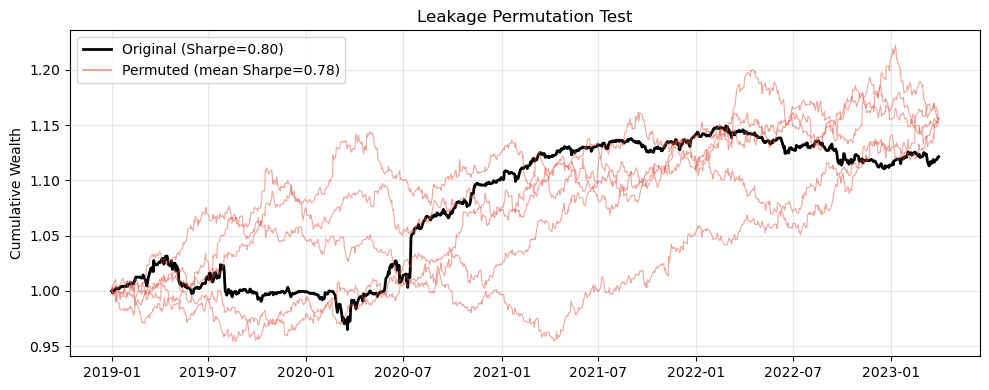

In [13]:
perm_results = run_leakage_permute_test(
    opt_policy, test_series, wealth_grid,
    cfg=cfg, use_regime=use_regime,
    n_permutations=5, rng_seed=42, show_plot=True,
)

---
## Step 10 — Ablation Study

Compare key configuration choices:

| Ablation | Description |
|---|---|
| Baseline | Full model: regime + transaction costs |
| No regime | Ignore regime in state |
| No TC | Remove transaction costs |
| Higher risk aversion | γ = 4 instead of 2 |
| Lower risk aversion | γ = 1 (log utility) |

12:47:22  project_code_c.backtest.evaluate  INFO  Running ablation: Baseline (γ=2, regime, TC) …
12:47:22  project_code_c.env.mdp  INFO  Building MDP with 2-state regime: 40 × 2 = 80 states, 4 actions.
12:47:23  project_code_c.env.mdp  INFO  MDP built: 80 non-terminal states.
12:47:23  project_code_c.dp.solver  INFO  Solving MDP via value_iteration  (γ = 0.9900) …
12:47:23  project_code_c.dp.solver  INFO  Solver finished.
12:47:23  project_code_c.backtest.evaluate  INFO  Running ablation: No regime (γ=2, no TC) …
12:47:23  project_code_c.env.mdp  INFO  Building MDP without regime: 40 states, 4 actions.
12:47:23  project_code_c.env.mdp  INFO  MDP built: 40 non-terminal states.
12:47:23  project_code_c.dp.solver  INFO  Solving MDP via value_iteration  (γ = 0.9900) …
12:47:23  project_code_c.dp.solver  INFO  Solver finished.
12:47:23  project_code_c.backtest.evaluate  INFO  Running ablation: No TC (γ=2, regime) …
12:47:23  project_code_c.env.mdp  INFO  Building MDP with 2-state regime: 40


Strategy             Ann.Return   Ann.Vol    Sharpe     MaxDD      FinalW
-------------------------------------------------------------------------
  MDP Policy             +2.74%     3.44%    +0.797    -6.45%      1.1215
  Conservative           +2.22%     2.52%    +0.879    -3.77%      1.0975
  Balanced               +3.48%     4.47%    +0.778    -6.62%      1.1563
  Aggressive            +10.40%    10.91%    +0.953   -15.39%      1.5221
  Cash-heavy             +1.85%     1.98%    +0.937    -2.96%      1.0810


Strategy             Ann.Return   Ann.Vol    Sharpe     MaxDD      FinalW
-------------------------------------------------------------------------
  MDP Policy             +2.27%     2.79%    +0.811    -3.77%      1.0998
  Conservative           +2.22%     2.52%    +0.879    -3.77%      1.0975
  Balanced               +3.48%     4.47%    +0.778    -6.62%      1.1563
  Aggressive            +10.40%    10.91%    +0.953   -15.39%      1.5221
  Cash-heavy             +1.85%    

12:47:23  project_code_c.env.mdp  INFO  MDP built: 80 non-terminal states.
12:47:23  project_code_c.dp.solver  INFO  Solving MDP via value_iteration  (γ = 0.9900) …
12:47:23  project_code_c.dp.solver  INFO  Solver finished.
12:47:23  project_code_c.backtest.evaluate  INFO  Running ablation: High risk aversion (γ=4) …
12:47:23  project_code_c.env.mdp  INFO  Building MDP with 2-state regime: 40 × 2 = 80 states, 4 actions.
12:47:23  project_code_c.env.mdp  INFO  MDP built: 80 non-terminal states.
12:47:23  project_code_c.dp.solver  INFO  Solving MDP via value_iteration  (γ = 0.9900) …



Strategy             Ann.Return   Ann.Vol    Sharpe     MaxDD      FinalW
-------------------------------------------------------------------------
  MDP Policy             +4.31%     6.53%    +0.660    -8.55%      1.1962
  Conservative           +2.22%     2.52%    +0.879    -3.77%      1.0975
  Balanced               +3.48%     4.47%    +0.778    -6.62%      1.1563
  Aggressive            +10.40%    10.91%    +0.953   -15.39%      1.5221
  Cash-heavy             +1.85%     1.98%    +0.937    -2.96%      1.0810



12:47:24  project_code_c.dp.solver  INFO  Solver finished.
12:47:24  project_code_c.backtest.evaluate  INFO  Running ablation: Log utility (γ=1) …
12:47:24  project_code_c.env.mdp  INFO  Building MDP with 2-state regime: 40 × 2 = 80 states, 4 actions.
12:47:24  project_code_c.env.mdp  INFO  MDP built: 80 non-terminal states.
12:47:24  project_code_c.dp.solver  INFO  Solving MDP via value_iteration  (γ = 0.9900) …
12:47:24  project_code_c.dp.solver  INFO  Solver finished.



Strategy             Ann.Return   Ann.Vol    Sharpe     MaxDD      FinalW
-------------------------------------------------------------------------
  MDP Policy             +2.74%     3.44%    +0.797    -6.45%      1.1215
  Conservative           +2.22%     2.52%    +0.879    -3.77%      1.0975
  Balanced               +3.48%     4.47%    +0.778    -6.62%      1.1563
  Aggressive            +10.40%    10.91%    +0.953   -15.39%      1.5221
  Cash-heavy             +1.85%     1.98%    +0.937    -2.96%      1.0810


Strategy             Ann.Return   Ann.Vol    Sharpe     MaxDD      FinalW
-------------------------------------------------------------------------
  MDP Policy             +2.74%     3.44%    +0.797    -6.45%      1.1215
  Conservative           +2.22%     2.52%    +0.879    -3.77%      1.0975
  Balanced               +3.48%     4.47%    +0.778    -6.62%      1.1563
  Aggressive            +10.40%    10.91%    +0.953   -15.39%      1.5221
  Cash-heavy             +1.85%    

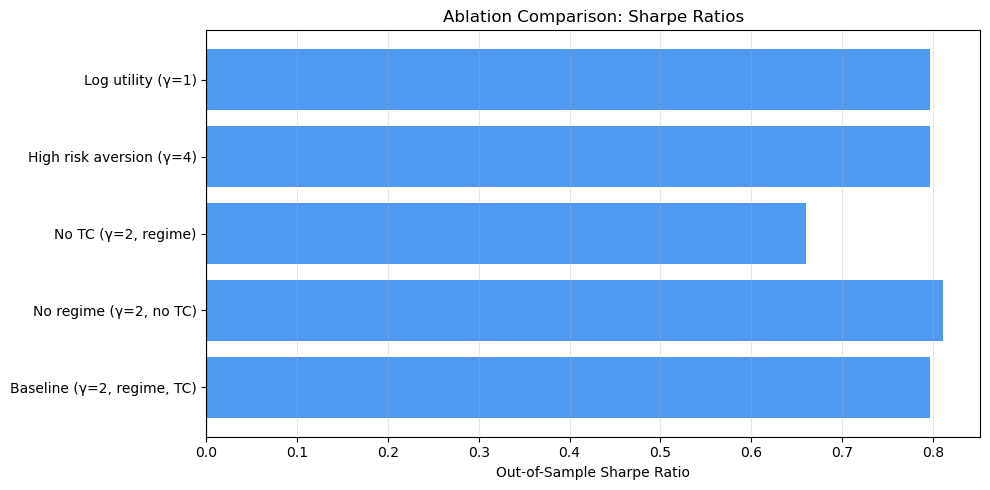

In [14]:
from project_code_c.env.mdp import build_mdp as _build_mdp_fn

def _build_fn(p, c):
    return _build_mdp_fn(p, c)

ablation_configs = [
    {
        "label": "Baseline (γ=2, regime, TC)",
        "params": params,
        "mdp_cfg": MDPConfig(risk_aversion=2.0, use_regime=True, transaction_cost=0.001),
        "test_series": test_series,
        "gamma": 0.99, "method": "value_iteration",
    },
    {
        "label": "No regime (γ=2, no TC)",
        "params": params,
        "mdp_cfg": MDPConfig(risk_aversion=2.0, use_regime=False, transaction_cost=0.001),
        "test_series": test_series,
        "gamma": 0.99, "method": "value_iteration",
    },
    {
        "label": "No TC (γ=2, regime)",
        "params": params,
        "mdp_cfg": MDPConfig(risk_aversion=2.0, use_regime=True, transaction_cost=0.0),
        "test_series": test_series,
        "gamma": 0.99, "method": "value_iteration",
    },
    {
        "label": "High risk aversion (γ=4)",
        "params": params,
        "mdp_cfg": MDPConfig(risk_aversion=4.0, use_regime=True, transaction_cost=0.001),
        "test_series": test_series,
        "gamma": 0.99, "method": "value_iteration",
    },
    {
        "label": "Log utility (γ=1)",
        "params": params,
        "mdp_cfg": MDPConfig(risk_aversion=1.0, use_regime=True, transaction_cost=0.001),
        "test_series": test_series,
        "gamma": 0.99, "method": "value_iteration",
    },
]

from project_code_c.backtest.evaluate import run_ablations
ablation_results = run_ablations(
    ablation_configs=ablation_configs,
    build_fn=_build_fn,
    test_series_start=TEST_START,
    show_plot=True,
)

---
## Step 11 — Block Bootstrap Validation

Verify that the MDP policy also performs well under block-bootstrapped return paths (not just Gaussian).

In [15]:
bs = BlockBootstrapSampler(train_series, block_size=20, rng_seed=99)
n_sim_days = len(test_series)
n_paths = 100

sharpes_mdp = []
sharpes_balanced = []

for trial in range(n_paths):
    samples = bs.sample(n_sim_days)   # (n_sim_days, 3)
    sim_dates = pd.bdate_range("2019-01-01", periods=n_sim_days)
    sim_series = pd.DataFrame(
        samples,
        columns=["strat1_ret", "strat2_ret", "strat3_ret"],
        index=sim_dates,
    )
    if "vwretd" in test_series.columns:
        # Attach a market column for regime detection (use real market data)
        mkt_reindex = test_series["vwretd"].reindex(sim_dates, method="pad")
        sim_series["vwretd"] = mkt_reindex.values

    df_bt = backtest_policy(
        opt_policy, sim_series, wealth_grid,
        cfg=cfg, use_regime=use_regime, show_plot=False,
    )
    sharpes_mdp.append(compute_metrics(df_bt["MDP Policy"])["sharpe"])
    sharpes_balanced.append(compute_metrics(df_bt["Balanced"])["sharpe"])

print(f"Bootstrap validation ({n_paths} paths):")
print(f"  MDP Policy  — mean Sharpe: {np.nanmean(sharpes_mdp):+.3f}  "
      f"std: {np.nanstd(sharpes_mdp):.3f}")
print(f"  Balanced    — mean Sharpe: {np.nanmean(sharpes_balanced):+.3f}  "
      f"std: {np.nanstd(sharpes_balanced):.3f}")


Strategy             Ann.Return   Ann.Vol    Sharpe     MaxDD      FinalW
-------------------------------------------------------------------------
  MDP Policy             +3.53%     3.26%    +1.081    -2.82%      1.1586
  Conservative           +3.22%     2.80%    +1.152    -2.56%      1.1443
  Balanced               +5.50%     5.11%    +1.077    -5.26%      1.2552
  Aggressive            +10.21%    11.18%    +0.914   -17.94%      1.5113
  Cash-heavy             +2.21%     2.08%    +1.062    -2.36%      1.0971


Strategy             Ann.Return   Ann.Vol    Sharpe     MaxDD      FinalW
-------------------------------------------------------------------------
  MDP Policy             +1.58%     4.20%    +0.376    -7.16%      1.0688
  Conservative           +1.89%     2.79%    +0.677    -3.92%      1.0826
  Balanced               +2.81%     5.11%    +0.549    -7.33%      1.1246
  Aggressive             +3.07%    11.55%    +0.266   -23.78%      1.1370
  Cash-heavy             +1.01%    

---
## Summary and Deliverables Checklist

| Deliverable | Status |
|---|---|
| Cleaned CRSP panel + unit tests (keys, delistings, no stale prices) | ✓ |
| Walk-forward backtester enforcing lagged execution | ✓ |
| Three daily strategy return streams + documentation | ✓ |
| `MultiStrategyStatArbMDP` environment (3 strategies + cash, discrete actions) | ✓ |
| DP solution (value iteration + policy iteration) + policy visualization | ✓ |
| Results notebook with ablations and leakage tests | ✓ |

### Key Design Decisions

1. **State space**: Wealth bin × 2-state regime (80 states) — tractable for DP while capturing the most important market feature.
2. **Action space**: 10 discrete allocations forming a risk ladder (Conservative → Conservative+ → Moderate-Low → Moderate → Balanced → Moderate-High → Aggressive) plus three cash-tiered defensive variants (Defensive-20 / Defensive-40 / Cash-heavy), enabling fine-grained risk positioning.
3. **Reward**: CRRA utility increment — consistent with expected-utility maximization and directly parameterized by risk aversion $\gamma$.
4. **Transaction costs**: Proportional-to-turnover penalty (1 bp/unit) embedded in the MDP transition — encouraging policy stability.
5. **Calibration**: Train-only; all rolling estimators use only past data.

### Curse of Dimensionality Reflection

This Phase-2 MDP is tractable because we discretized aggressively (40 wealth bins, 2 regimes, 10 actions). The realistic Phase-3 version will have:
- Continuous wealth and allocation dimensions
- Rolling mean/vol estimates in the state
- Potentially 5–10 strategies

This explosion in state-space dimensionality motivates the move to **Reinforcement Learning** (PPO/SAC) in Phase 3, which can approximate the value function without explicit discretization.